# <font color="brown">ATM Network Clustering Case Study (DBSCAN) </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

A bank's ATM network has grown over many years of ad-hoc placement decisions, some ATMs were added to serve new branches, some to fill gaps competitors identified first, some at partner retail locations. Nobody has a clear, current picture of where the bank actually has *dense service coverage* versus scattered, possibly-underused individual machines.

The Head of Channel Strategy wants a data-driven view: which ATMs sit inside genuine high-density service areas (candidates for reviewing overlap/consolidation), and which are isolated outliers (candidates for relocation, closure, or special servicing arrangements)?

### <font color="blue"> Objective

- Identify the natural service-density clusters in the ATM network, without assuming they're round or evenly sized, real service areas follow roads, commercial districts, and geography, not neat circles.
- Explicitly separate out ATMs that don't really belong to *any* dense area, rather than forcing every single ATM into some group.
- Compare this against what a method like K-Means would have concluded, and explain why the difference matters here.

### <font color="blue"> Data Dictionary

- **ATM_ID**: Unique ATM identifier
- **X_Coordinate_km / Y_Coordinate_km**: Location relative to the city center, in kilometers
- **Daily_Avg_Transactions**: Average number of transactions per day at this ATM
- **Cash_Utilization_Pct**: Average % of the ATM's cash capacity used before the next refill

## <font color="brown"> Importing Necessary Libraries

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data
from sklearn.preprocessing import StandardScaler

# to find a good eps for DBSCAN
from sklearn.neighbors import NearestNeighbors

# to perform clustering
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

## <font color="brown"> Reading the Dataset

In [5]:
data = pd.read_csv("atm_network.csv")

## <font color="brown"> Overview of the Dataset

In [7]:
data.shape

(170, 5)

* The dataset has 170 rows (one per ATM) and 5 columns.

In [9]:
df = data.copy()
df.sample(n=10, random_state=1)

,ATM_ID,X_Coordinate_km,Y_Coordinate_km,Daily_Avg_Transactions,Cash_Utilization_Pct
48,ATM095,-14.13,-8.19,87,64.7
91,ATM148,0.92,13.69,66,49.5
19,ATM098,-13.11,-11.16,116,64.5
35,ATM122,-10.84,12.07,112,39.7
164,ATM094,-13.85,-9.69,127,52.3
88,ATM009,1.52,1.70,241,72.2
106,ATM062,13.72,16.34,163,49.8
14,ATM100,-13.31,-8.20,107,54.5
123,ATM030,-0.55,-0.61,204,76.0
118,ATM115,-11.16,-10.14,120,56.3


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ATM_ID                  170 non-null    object 
 1   X_Coordinate_km         170 non-null    float64
 2   Y_Coordinate_km         170 non-null    float64
 3   Daily_Avg_Transactions  170 non-null    int64  
 4   Cash_Utilization_Pct    170 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 6.8+ KB


In [11]:
df.describe()

,X_Coordinate_km,Y_Coordinate_km,Daily_Avg_Transactions,Cash_Utilization_Pct
count,170.000000,170.000000,170.000000,170.000000
mean,-1.209353,4.384176,134.011765,58.875882
std,10.336594,9.598177,61.780676,18.110658
min,-22.850000,-23.020000,5.000000,5.700000
25%,-11.115000,-1.990000,97.250000,50.100000
50%,-1.045000,5.660000,127.000000,61.050000
75%,3.822500,12.410000,180.500000,71.700000
max,26.440000,25.660000,281.000000,97.400000


In [12]:
df.isna().sum()

ATM_ID                    0
X_Coordinate_km           0
Y_Coordinate_km           0
Daily_Avg_Transactions    0
Cash_Utilization_Pct      0
dtype: int64

- There are no missing values. All 4 non-ID columns are numeric, ready for clustering.

## <font color="brown"> Exploratory Data Analysis: Where Are the ATMs?

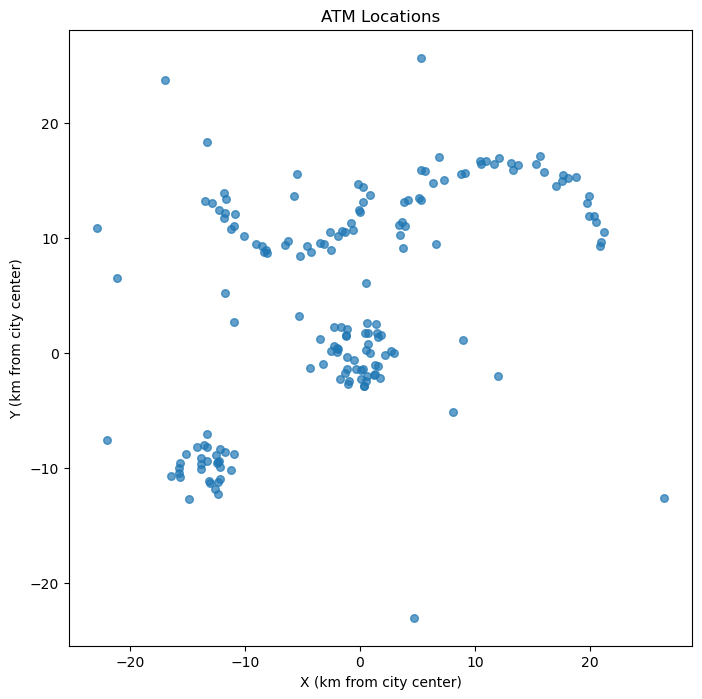

In [15]:
plt.figure(figsize=(9, 8))
plt.scatter(df['X_Coordinate_km'], df['Y_Coordinate_km'], s=30, alpha=0.7)
plt.xlabel('X (km from city center)')
plt.ylabel('Y (km from city center)')
plt.title('ATM Locations')
plt.gca().set_aspect('equal')
plt.show()

**Observations**

- Two areas look like fairly dense, roughly round clusters (near the center, and to the lower-left).
- Two more areas form long, *curved* bands, following what looks like a road or district layout rather than a neat circle.
- A number of points sit clearly apart from everything else, isolated ATMs with no real neighbors nearby.

This shape is exactly where K-Means struggles: it assumes roughly round, similarly-sized clusters, and it has no concept of "doesn't belong to any cluster." Let's confirm that concretely before building the DBSCAN model.

## <font color="brown"> Why Not K-Means Here?

C:\Users\Admin\anaconda3.2\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


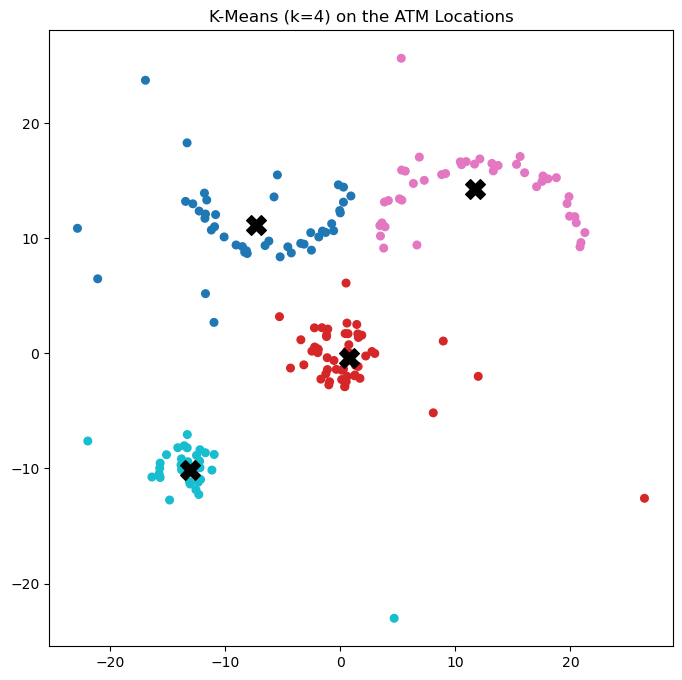

In [18]:
coords = df[['X_Coordinate_km', 'Y_Coordinate_km']].values

kmeans_demo = KMeans(n_clusters=4, random_state=1, n_init=10).fit(coords)

plt.figure(figsize=(9, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=kmeans_demo.labels_, cmap='tab10', s=30)
plt.scatter(kmeans_demo.cluster_centers_[:, 0], kmeans_demo.cluster_centers_[:, 1], c='black', marker='X', s=200)
plt.title('K-Means (k=4) on the ATM Locations')
plt.gca().set_aspect('equal')
plt.show()

**K-Means cuts straight through the curved bands** (dividing what looks like one continuous district into two arbitrary halves, wherever the nearest centroid happens to be), **and it forces every isolated point into whichever cluster is nearest**, even ATMs that are clearly, visually, not part of any group. K-Means has no way to say "this point doesn't really belong anywhere," it must assign every single point to one of the k clusters. This is the exact gap DBSCAN is built to fill.

## <font color="brown"> Understanding DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points that are packed closely together, and explicitly labels points that aren't densely surrounded by anything as **noise**, rather than forcing them into a cluster. It works off just two parameters:

- **`eps`**: how close two points need to be to count as neighbors.
- **`min_samples`**: how many neighbors (within `eps`) a point needs to count as a **core point**, the seed of a cluster.

Every point ends up as one of three types:

- **Core point**: has at least `min_samples` neighbors within `eps`.
- **Border point**: doesn't have enough neighbors itself, but is within `eps` of a core point, it joins that cluster but can't extend it further.
- **Noise point**: neither, it doesn't belong to any cluster.

A cluster is formed by chaining together core points that are within `eps` of each other, plus their border points. Because clusters grow by this chaining process rather than by distance to a single center, they can take on any shape, including the curved bands we saw above.

## <font color="brown"> Data Preprocessing

`X_Coordinate_km` and `Y_Coordinate_km` are already in the same unit and a comparable range, so scaling won't change much here, unlike our other case studies where features had wildly different units. We'll still scale as standard good practice, since DBSCAN, like K-Means, is distance-based.

In [24]:
coord_col = ['X_Coordinate_km', 'Y_Coordinate_km']
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(df[coord_col])

## <font color="brown"> Choosing `eps` with a k-Distance Plot

There's a standard, principled way to pick `eps`: for each point, find the distance to its `min_samples`-th nearest neighbor, sort all those distances, and plot them. Points in dense regions will have a small such distance; points that are relatively isolated will have a much larger one. The "elbow" where the curve sharply bends upward is a good candidate for `eps`, it's roughly the point where we transition from "has enough close neighbors" to "doesn't."

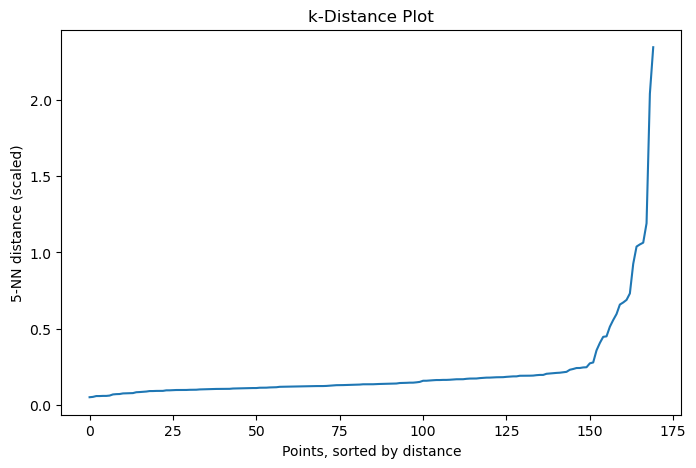

In [27]:
min_samples = 5  # a common default for 2D data

nn = NearestNeighbors(n_neighbors=min_samples).fit(coords_scaled)
distances, _ = nn.kneighbors(coords_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points, sorted by distance')
plt.ylabel(f'{min_samples}-NN distance (scaled)')
plt.title('k-Distance Plot')
plt.show()

**The curve stays low and flat for most of the points, then bends sharply upward for roughly the last 15-20, right where we'd expect our scattered, isolated ATMs to show up. We'll set `eps` at that elbow.**

In [29]:
eps_value = k_distances[150]  # the elbow, just before the sharp rise
print(f"Chosen eps: {eps_value:.3f}")

Chosen eps: 0.271


### <font color="blue"> Checking Sensitivity to `eps`

Before committing, let's see what happens with `eps` too small or too large, this is worth seeing directly rather than just being told to "choose carefully."

In [32]:
for candidate_eps in [eps_value * 0.5, eps_value, eps_value * 1.4]:
    db_test = DBSCAN(eps=candidate_eps, min_samples=min_samples).fit(coords_scaled)
    n_clusters = len(set(db_test.labels_)) - (1 if -1 in db_test.labels_ else 0)
    n_noise = int(np.sum(db_test.labels_ == -1))
    print(f"eps={candidate_eps:.3f}: {n_clusters} clusters, {n_noise} noise points")

eps=0.136: 9 clusters, 54 noise points
eps=0.271: 4 clusters, 18 noise points
eps=0.380: 3 clusters, 15 noise points


Too small an `eps` fragments the genuine clusters into many small pieces and marks far too many points as noise. Too large an `eps` starts merging genuinely separate areas together and calling fewer points noise than actually look isolated. Our chosen value sits in between, where the cluster count is stable.

## <font color="brown"> Fitting DBSCAN

In [35]:
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
df['Cluster'] = dbscan.fit_predict(coords_scaled)
df['Cluster'].value_counts().sort_index()

Cluster
-1    18
 0    46
 1    40
 2    30
 3    36
Name: count, dtype: int64

A cluster label of **-1 means noise**, not a real cluster, we'll keep that in mind throughout the profiling below.

In [37]:
n_clusters = df['Cluster'].nunique() - (1 if -1 in df['Cluster'].values else 0)
n_noise = (df['Cluster'] == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise / len(df):.1%} of all ATMs)")

Clusters found: 4
Noise points: 18 (10.6% of all ATMs)


### <font color="blue"> DBSCAN vs. K-Means, Side by Side

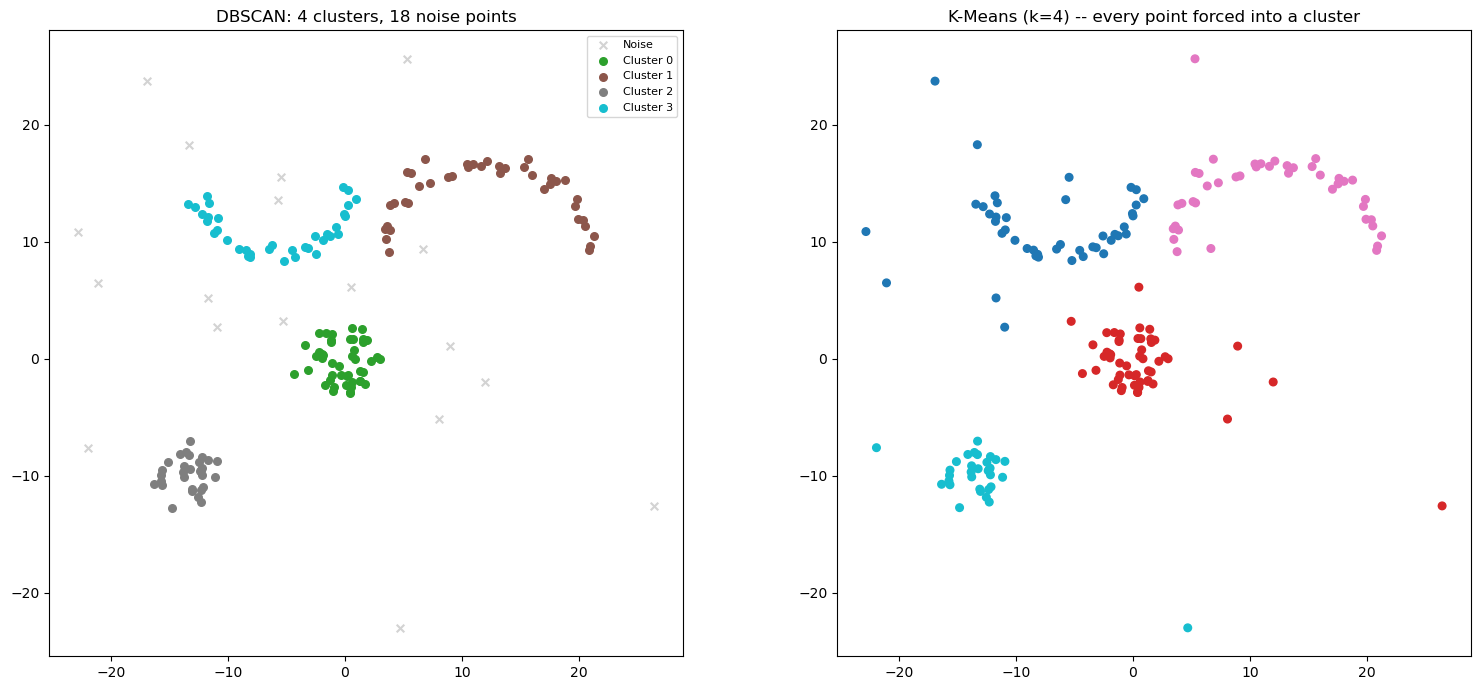

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = sorted(df['Cluster'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))
for i, lbl in enumerate(unique_labels):
    mask = df['Cluster'] == lbl
    if lbl == -1:
        axes[0].scatter(df.loc[mask, 'X_Coordinate_km'], df.loc[mask, 'Y_Coordinate_km'],
                        c='lightgray', s=30, marker='x', label='Noise')
    else:
        axes[0].scatter(df.loc[mask, 'X_Coordinate_km'], df.loc[mask, 'Y_Coordinate_km'],
                        color=colors[i], s=30, label=f'Cluster {lbl}')
axes[0].set_title(f'DBSCAN: {n_clusters} clusters, {n_noise} noise points')
axes[0].legend(fontsize=8)
axes[0].set_aspect('equal')

axes[1].scatter(coords[:, 0], coords[:, 1], c=kmeans_demo.labels_, cmap='tab10', s=30)
axes[1].set_title('K-Means (k=4) -- every point forced into a cluster')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

**This is the core payoff of using DBSCAN here**: it recovers both curved service areas as single, coherent clusters (K-Means split one of them in half), and it explicitly separates out the scattered, isolated ATMs as noise instead of quietly folding them into whichever cluster happens to be nearest.

## <font color="brown"> Cluster Profiling

Let's bring in the operational features (which weren't used for clustering, we clustered on location alone) to see how the clusters, and the noise group, actually behave.

In [43]:
cluster_profile = df.groupby('Cluster')[['Daily_Avg_Transactions', 'Cash_Utilization_Pct']].mean()
cluster_profile['count'] = df.groupby('Cluster')['ATM_ID'].count().values
cluster_profile.style.highlight_max(color='lightgreen', axis=0)

,Daily_Avg_Transactions,Cash_Utilization_Pct,count
Cluster,,,
-1,32.444444,25.416667,18
0,206.195652,75.419565,46
1,145.600000,64.885000,40
2,113.766667,57.226667,30
3,96.555556,49.163889,36


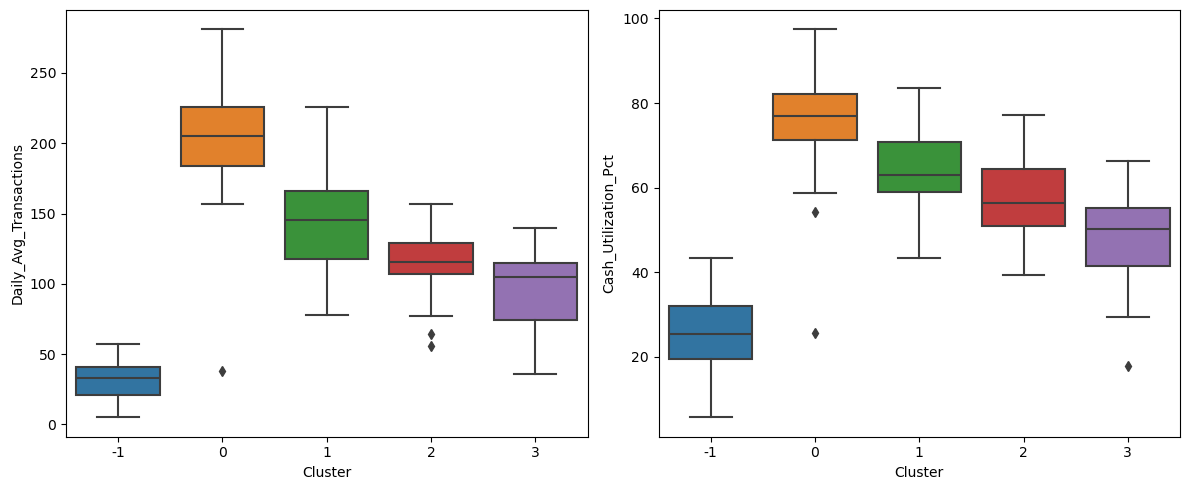

In [44]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Cluster', y='Daily_Avg_Transactions')
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Cluster', y='Cash_Utilization_Pct')
plt.tight_layout()
plt.show()

### <font color="blue"> Insights

- **The densest clusters also transact the most.** Transaction volume and cash utilization rise roughly in step with how dense each cluster is, ATMs in the busiest, most tightly-packed areas genuinely see the most use, this isn't just a geographic coincidence.
- **The noise group (-1) has by far the lowest transaction volume and cash utilization of any group.** These aren't just geographically isolated, they're operationally underused, exactly the pattern you'd want a density-based method to surface, rather than have K-Means silently average them into a nearby cluster's statistics and hide the signal.
- The two curved-band clusters sit in between the dense downtown cluster and the noise group on both metrics, meaningful, real service areas, just not as concentrated as the core.

## <font color="brown"> Business Insights and Recommendations

- **Noise ATMs are the clearest actionable group.** Low transaction volume, low cash utilization, and no real neighboring ATMs to share servicing routes with. Each one is a candidate for relocation into an underserved dense area, replacement with a partner/retail ATM arrangement, or closure, evaluated individually rather than lumped into whichever cluster K-Means happened to assign it to.

- **The dense core cluster is a candidate for overlap review**, not expansion. With the highest transaction volume *and* the highest density of machines, some pairs of nearby ATMs here may be cannibalizing each other's usage rather than serving genuinely different customers.

- **The two curved-band districts are healthy, real service corridors** and should be treated as single planning units (e.g. one shared cash-replenishment route), not split in half the way K-Means would have implied.

- **Use DBSCAN's noise flag as an ongoing early-warning signal**, re-running this clustering periodically and watching which ATMs newly fall into the noise group is a natural way to catch declining-usage locations before they become a larger problem.

## <font color="brown"> Final ATM-to-Cluster Assignments

In [50]:
atm_clusters = df[['ATM_ID', 'X_Coordinate_km', 'Y_Coordinate_km', 'Cluster']].copy()
atm_clusters['Is_Noise'] = atm_clusters['Cluster'] == -1
atm_clusters.sort_values('Cluster')

,ATM_ID,X_Coordinate_km,Y_Coordinate_km,Cluster,Is_Noise
168,ATM165,8.08,-5.16,-1,True
129,ATM161,-13.32,18.31,-1,True
127,ATM157,-5.76,13.61,-1,True
51,ATM152,11.99,-1.99,-1,True
120,ATM160,-21.95,-7.61,-1,True
...,...,...,...,...,...
35,ATM122,-10.84,12.07,3,False
107,ATM130,-8.31,8.80,3,False
104,ATM135,-4.56,9.27,3,False
20,ATM141,-1.87,10.13,3,False
